This project follows our previous implementation of Group Relative Policy Optimization for the sliding puzzle. We are now applying the same GRPO framework to time-series curve data with the primary objective of maximizing portfolio profit.

The current phase uses synthetic curves that alternate strictly between values of five and ten. This simplified dataset serves as a benchmark to verify the learning capabilities of the model in a controlled environment.

We expect the agent to identify this pattern and execute the optimal strategy by buying when the price is five and selling when it reaches ten. Success in this scenario validates the algorithm logic before we move toward more complex data.

In [89]:
from typing import Callable, Tuple
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import torch.nn.functional as F
import copy
from collections import deque
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [90]:
def run_policy(num_samples: int,
               num_steps: int,
               env_context: dict,
               context_modifier: Callable[[dict], dict],
               initial_states: torch.Tensor,
               initial_inputs: torch.Tensor,
               policy_net: torch.nn.Module,
               transition_fn: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor],
               reward_fn: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Executes the policy over multiple parallel trajectories for GRPO.
    initial_states shape: (batch_size, num_assets, state_dim)
    initial_inputs shape: (batch_size, input_dim)
    Returns:
    states: (batch_size, num_samples, num_steps, num_assets, state_dim)
    inputs: (batch_size, num_samples, num_steps, input_dim)
    actions: (batch_size, num_samples, num_steps, num_assets + 1)
    rewards: (batch_size, num_samples, num_steps)
    predictions: (batch_size, num_samples, num_steps, num_assets + 1, num_actions)
    """

    current_states = initial_states.repeat_interleave(num_samples, dim=0).clone()
    current_inputs = initial_inputs.repeat_interleave(num_samples, dim=0).clone()
    current_context = context_modifier(env_context)

    current_predictions, current_logits = policy_net(current_inputs)
    current_dist = Categorical(logits=current_logits)
    current_actions = current_dist.sample()

    states_history = torch.zeros(num_steps, *current_states.shape)
    inputs_history = torch.zeros(num_steps, *current_inputs.shape)
    actions_history = torch.zeros(num_steps, *current_actions.shape)
    rewards_history = torch.zeros(num_steps, current_actions.shape[0])
    predictions_history = torch.zeros(num_steps, *current_predictions.shape)

    states_history[0] = current_states.clone()
    inputs_history[0] = current_inputs.clone()
    actions_history[0] = current_actions
    rewards_history[0] = reward_fn(current_context, current_states, current_actions)
    predictions_history[0] = current_predictions

    current_states, current_inputs = transition_fn(current_context, current_states, current_actions)

    for i in range(num_steps - 1):
        current_predictions, current_logits = policy_net(current_inputs)
        current_dist = Categorical(logits=current_logits)
        current_actions = current_dist.sample()

        states_history[i+1] = current_states.clone()
        inputs_history[i+1] = current_inputs.clone()
        predictions_history[i+1] = current_predictions
        actions_history[i+1] = current_actions
        rewards_history[i+1] = reward_fn(current_context, current_states, current_actions)

        current_states, current_inputs = transition_fn(current_context, current_states, current_actions)

    num_initial_states = initial_states.shape[0]
    state_dims = initial_states.shape[1:]
    input_dims = initial_inputs.shape[1:]

    actions_history = actions_history.view(num_steps, num_initial_states, num_samples, -1)
    actions_history = actions_history.permute(1, 2, 0, 3)

    rewards_history = rewards_history.view(num_steps, num_initial_states, num_samples).permute(1, 2, 0)

    states_history = states_history.view(num_steps, num_initial_states, num_samples, *state_dims)
    states_history = states_history.permute(1, 2, 0, 3, 4)

    inputs_history = inputs_history.view(num_steps, num_initial_states, num_samples, *input_dims)
    inputs_history = inputs_history.permute(1, 2, 0, 3)

    predictions_history = predictions_history.view(num_steps, num_initial_states, num_samples, actions_history.shape[-1], -1)
    predictions_history = predictions_history.permute(1, 2, 0, 3, 4)

    return states_history, inputs_history, actions_history, rewards_history, predictions_history

In [91]:
def run_actions(env_context: dict,
                initial_states: torch.Tensor,
                actions_sequence: torch.Tensor,
                transition_fn: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor],
                reward_fn: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Runs a predefined sequence of actions through the environment.
    initial_states shape: (batch_size, num_assets, state_dim)
    actions_sequence shape: (batch_size, num_steps, num_assets + 1)
    Returns:
    states: (num_steps, batch_size, num_assets, state_dim)
    rewards: (num_steps, batch_size)
    """

    current_states = initial_states
    current_context = copy.deepcopy(env_context)
    num_steps = actions_sequence.shape[1]

    states_history = torch.zeros(num_steps, *current_states.shape)
    rewards_history = torch.zeros(num_steps, current_states.shape[0])

    for i in range(num_steps):
        current_actions = actions_sequence[:, i]
        states_history[i] = current_states.clone()
        rewards_history[i] = reward_fn(current_context, current_states, current_actions)
        current_states, _ = transition_fn(current_context, current_states, current_actions)

    return states_history, rewards_history

In [92]:
def calculate_group_advantage(rewards: torch.Tensor, gamma: float) -> torch.Tensor:
    """
    Calculates the relative advantage within the group for GRPO.
    rewards shape: (batch_size, num_samples, num_steps)
    Returns:
    advantage shape: (batch_size, num_samples)
    """
    num_steps = rewards.shape[2]
    gamma_powers = torch.pow(gamma, torch.arange(num_steps).float().to(rewards.device))

    discounted_rewards = rewards * gamma_powers.view(1, 1, num_steps)
    returns = torch.sum(discounted_rewards, dim=2)

    mean_returns = torch.mean(returns, dim=1, keepdim=True)
    std_returns = torch.std(returns, dim=1, keepdim=True, correction=0)

    return (returns - mean_returns) / (std_returns + 1e-8)

In [93]:
def compute_grpo_loss(current_dist_probs: torch.Tensor,
                      old_dist_probs: torch.Tensor,
                      actions: torch.Tensor,
                      advantages: torch.Tensor,
                      epsilon: float):
    """
    Computes the GRPO loss with clipping.
    current_dist_probs shape: (total_batch, num_assets + 1, num_actions)
    old_dist_probs shape: (total_batch, num_assets + 1, num_actions)
    actions shape: (total_batch, num_assets + 1)
    advantages shape: (total_batch)
    """
    indices = actions.unsqueeze(-1).long()

    prob_actions = torch.gather(current_dist_probs, dim=-1, index=indices).squeeze(-1).prod(dim=1)
    old_prob_actions = torch.gather(old_dist_probs, dim=-1, index=indices).squeeze(-1).prod(dim=1)

    ratio = torch.exp(torch.log(prob_actions + 1e-8) - torch.log(old_prob_actions + 1e-8))
    surrogate1 = ratio * advantages
    surrogate2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantages

    return torch.mean(torch.min(surrogate1, surrogate2))

In [94]:
class MultiQueueBuffer:
    """
    Replay buffer designed to manage multiple training trajectories.
    """
    def __init__(self, max_size):
        self.max_size = max_size
        self.queues = {}
        self.current_size = 0

    def append(self, data_dict):
        for key, value in data_dict.items():
            if not isinstance(value, torch.Tensor):
                continue
            data = value.detach()
            if key not in self.queues:
                self.queues[key] = data
            else:
                self.queues[key] = torch.cat([self.queues[key], data], dim=0)

        if self.queues:
            self.current_size = self.queues[next(iter(self.queues))].size(0)

        if self.current_size > self.max_size:
            for key in self.queues:
                self.queues[key] = self.queues[key][-self.max_size:]
            self.current_size = self.max_size

    def get_batches(self, batch_size):
        if self.current_size == 0:
            return
        indices = torch.randperm(self.current_size)
        for i in range(0, self.current_size, batch_size):
            batch_idx = indices[i : i + batch_size]
            yield {key: self.queues[key][batch_idx] for key in self.queues}

    def clear(self):
        self.queues = {}
        self.current_size = 0

    def __len__(self):
        return self.current_size

In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

class DenseTradingPolicy(nn.Module):
    def __init__(self, num_assets, flexibility, num_features, hidden_size):
        super().__init__()
        self.num_assets = num_assets
        self.flexibility = flexibility
        self.num_features = num_features
        self.output_rows = num_assets + 1
        self.output_cols = 2 * flexibility + 1

        input_dim = 1 + num_assets * num_features
        output_dim = self.output_rows * self.output_cols

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        logits = logits.view(-1, self.output_rows, self.output_cols)
        return F.softmax(logits, dim=-1), logits

class OnlyBuyPolicy(nn.Module):
    def __init__(self, num_assets, flexibility, num_features, hidden_size):
        super().__init__()
        self.num_assets = num_assets
        self.flexibility = flexibility
        self.output_rows = num_assets + 1
        self.output_cols = 2 * flexibility + 1

    def forward(self, x):
        probs = torch.zeros((x.shape[0], self.output_rows, self.output_cols)).to(x.device)
        probs[:, 0, self.output_cols-1] = 1
        probs[:, 1:, 0] = 1
        return probs, probs * 10000

class RandomPolicy(nn.Module):
    def __init__(self, num_assets, flexibility, num_features, hidden_size):
        super().__init__()
        self.num_assets = num_assets
        self.flexibility = flexibility
        self.output_rows = num_assets + 1
        self.output_cols = 2 * flexibility + 1

    def forward(self, x):
        probs = torch.zeros((x.shape[0], self.output_rows, self.output_cols)).to(x.device)
        probs[:, 0, self.output_cols-1] = 1
        probs[:, 1:, 0] = 1
        return probs, probs * 10000

cuda


In [96]:
def get_teacher_actions(prices: torch.Tensor, neighbor: int, flexibility: int):
    """
    Generates target actions based on a local price oracle.
    prices shape: (T, num_assets)
    """
    device = prices.device
    time_steps, num_assets = prices.shape

    buy_signals = torch.zeros_like(prices)
    sell_signals = torch.zeros_like(prices)

    for t in range(neighbor, time_steps - neighbor):
        mean_before = prices[t - neighbor : t, :].mean(dim=0)
        mean_after = prices[t + 1 : t + 1 + neighbor, :].mean(dim=0)
        current_val = prices[t, :]

        buy_signals[t, :] = ((mean_before > current_val) & (mean_after > current_val)).float()
        sell_signals[t, :] = ((mean_before < current_val) & (mean_after < current_val)).float()

    actions = torch.full((time_steps, num_assets + 1), flexibility, dtype=torch.long, device=device)
    actions[:, 0] = 0
    actions[buy_signals.any(dim=1), 0] = 2 * flexibility

    for i in range(num_assets):
        actions[buy_signals[:, i] == 1, i + 1] = 0
        actions[sell_signals[:, i] == 1, i + 1] = 2 * flexibility

    return actions, buy_signals, sell_signals

In [97]:
def plot_trade_actions(prices: torch.Tensor, actions: torch.Tensor, asset_idx: int, flexibility: int, title: str = ""):
    """
    Visualizes the price evolution of a specific asset along with buy and sell signals.

    Args:
        prices (torch.Tensor): Tensor containing price history. Shape (num_steps, num_assets).
        actions (torch.Tensor): Tensor containing action history. Shape (num_steps, num_assets + 1).
        asset_idx (int): The index of the asset to be displayed.
        flexibility (int): The reference threshold to categorize actions as buy, hold, or sell.
        title (str): Optional title for the generated plot.
    """
    prices_cpu = prices.cpu().detach().numpy()
    actions_cpu = actions.cpu().detach().numpy()
    curve_data = prices_cpu[:, asset_idx]
    asset_actions = actions_cpu[:, asset_idx + 1]

    buy_indices = np.argwhere(asset_actions < flexibility).flatten()
    sell_indices = np.argwhere(asset_actions > flexibility).flatten()

    plt.style.use('dark_background')
    plt.figure(figsize=(15, 7))

    plt.plot(curve_data, color='white', linewidth=1.5, label='Price')

    if buy_indices.size > 0:
        plt.scatter(buy_indices, curve_data[buy_indices],
                    color='#00FF00', marker='^', s=100, label='Buy Signal')

    if sell_indices.size > 0:
        plt.scatter(sell_indices, curve_data[sell_indices],
                    color='#FF0000', marker='v', s=100, label='Sell Signal')

    if title:
        plt.title(title)
    else:
        plt.title(f"Trading Signals - Asset {asset_idx}")

    plt.legend()
    plt.show()

In [98]:
def get_prices_features(prices, lookback):
    """
    Computes price variations over a sliding window.
    prices shape: (T, num_assets)
    """
    time_steps, num_assets = prices.shape
    variations = torch.zeros_like(prices)
    variations[1:] = (prices[1:] - prices[:-1]) / (prices[:-1] + 1e-7)
    padding = torch.zeros((lookback - 1, num_assets), device=prices.device)
    padded_vars = torch.cat([padding, variations], dim=0)
    windows = padded_vars.unfold(0, lookback, 1)
    return torch.flip(windows, dims=[2])

In [99]:
def helpers_modifier(env_context: dict):
    current_context = copy.deepcopy(env_context)
    num_samples = current_context["samples"]
    current_context["indices"] = current_context["indices"].repeat_interleave(num_samples, dim=0)
    current_context["sleep_deficit"] = current_context["sleep_deficit"].repeat_interleave(num_samples, dim=0)
    return current_context

In [100]:
def build_inputs(states: torch.Tensor, features: torch.Tensor, actual_prices: torch.Tensor):
    """
    Constructs the input vector for the network.
    states shape: (batch_size, num_assets, 3)
    features shape: (batch_size, num_assets, num_features)
    """
    device = states.device
    batch_size, num_assets, _ = states.shape
    num_feat = features.shape[2]

    liquidity = states[:, 0, 0]
    shares = states[:, :, 1]
    purchase_prices = states[:, :, 2]

    wallet_values = (liquidity + torch.sum(actual_prices * shares, dim=1)).unsqueeze(-1)

    n_liquidity = (liquidity / wallet_values).unsqueeze(-1)
    n_benefits = ((shares * actual_prices - purchase_prices) / wallet_values).unsqueeze(-1)
    n_purchase_prices = (purchase_prices / wallet_values).unsqueeze(-1)

    x = torch.zeros((batch_size, 1 + num_assets * (2 + num_feat))).to(device)
    x[:, 0] = n_liquidity[:, 0, 0]
    x[:, 1:] = torch.cat([n_benefits, n_purchase_prices, features], dim=2).flatten(1, 2)
    return x

In [101]:
def torch_wallet_value(actual_prices, liquidity, shares):
    return torch.round(liquidity + torch.sum(actual_prices * shares, dim=1), decimals=5)

In [102]:
def torch_reward(env_context, states, actions):
    """
    Calculates the reward and updates the environment internal state.
    states shape: (batch_size, num_assets, 3)
    actions shape: (batch_size, num_assets + 1)
    """
    batch_size, num_plus_one = actions.shape
    num_assets = num_plus_one - 1
    flex = env_context["flexibility"]
    num_classes = 2 * flex + 1
    idx = env_context["indices"]

    one_hot_actions = F.one_hot(actions.long(), num_classes=num_classes).to(states.dtype)
    actual_prices = env_context["prices"][idx]
    new_prices = env_context["prices"][idx + 1]
    new_features = env_context["features"][idx + 1]

    liquidity = states[:, 0, 0].clone()
    shares = states[:, :, 1].clone()
    purchase_prices = states[:, :, 2].clone()
    old_val = torch_wallet_value(actual_prices, liquidity, shares)

    sell_levels = torch.arange(flex + 1, device=states.device).float() / flex
    sell_fractions = torch.sum(one_hot_actions[:, 1:, flex:] * sell_levels, dim=2)
    sell_shares = sell_fractions * shares * (shares > 0).float()

    shares -= sell_shares
    purchase_prices -= sell_fractions * purchase_prices
    liquidity += torch.sum(sell_shares * actual_prices, dim=1)

    buy_levels = torch.flip(torch.arange(flex + 1, device=states.device).float() / flex, dims=[0])
    liq_levels = torch.arange(num_classes, device=states.device).float() / (num_classes - 1)

    liq_fraction = torch.sum(one_hot_actions[:, 0, :] * liq_levels, dim=1)
    investment = liq_fraction * liquidity

    buy_fractions = torch.sum(one_hot_actions[:, 1:, :flex+1] * buy_levels, dim=2)
    buy_sum = torch.sum(buy_fractions, dim=1)

    alloc = torch.zeros_like(buy_sum)
    mask = (buy_sum > 0) & (investment > 0)
    alloc[mask] = 1.0 / buy_sum[mask]

    liquidity[mask] -= investment[mask]
    buy_tx = (alloc.unsqueeze(1) * buy_fractions) * investment.unsqueeze(1)

    shares += buy_tx / actual_prices
    purchase_prices += buy_tx

    new_val = torch_wallet_value(new_prices, liquidity, shares)

    new_states = torch.stack([liquidity.unsqueeze(-1).repeat(1, num_assets), shares, purchase_prices], dim=2)
    new_states[:, 1, 0] = new_val

    env_context["new_states"] = new_states
    env_context["new_inputs"] = build_inputs(new_states, new_features, new_prices)
    env_context["sleep_deficit"] = env_context["sleep_deficit"] * (1 + env_context["beta"])
    env_context["sleep_deficit"][torch.all(new_states != states, dim=(1, 2))] = 1

    return (new_val - old_val) / (old_val + 1e-7) + (1 - env_context["sleep_deficit"]) * env_context["gamma_penalty"]

In [103]:
def torch_transition(env_context, states, actions):
    env_context["indices"] = env_context["indices"] + 1
    return env_context["new_states"], env_context["new_inputs"]

In [104]:
# --- Hyperparameters and Initialization ---
nb_batches = 64
start_samples, end_samples = 128, 32
batch_size, steps = 16, 16
gamma_rl = 0.99
K_epochs = 1
alpha, alpha_factor = 1.0, 0.99
beta, gamma_penalty = 0.01, 0.01
entropy_weight = 0.2
buffer_batch_size = 1024
M, lookback = 2, 4
T, n_assets = 2**10, 3
flexibility = 2
n_features = 2 + lookback

prices = torch.full((T, n_assets), 5.0).to(device)
prices[::2, :] = 10.0
features = get_prices_features(prices, lookback)
features = 2 * (features - features.min()) / (features.max() - features.min() + 1e-7) - 1

train_T = int(T * 0.75)
train_prices, train_features = prices[:train_T], features[:train_T]
test_prices, test_features = prices[train_T:], features[train_T:]

policy = DenseTradingPolicy(n_assets, flexibility, n_features, 32).to(device)
optimizer = torch.optim.Adam(policy.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=64, gamma=0.5)
simulation_buffer = MultiQueueBuffer(batch_size * max(start_samples, end_samples) * steps * M)

# --- Training Loop ---
policy.train()
pbar = tqdm(range(nb_batches))
for i in pbar:
    curr_samples = int((1 - i/nb_batches) * start_samples + (i/nb_batches) * end_samples)

    init_states = torch.rand((batch_size, n_assets, 3)).to(device) * 200
    indices = torch.randint(0, train_T - steps - 1, (batch_size,))
    init_inputs = build_inputs(init_states, train_features[indices], train_prices[indices])

    ctx = {"prices": train_prices, "n_assets": n_assets, "flexibility": flexibility,
           "indices": indices, "features": train_features, "beta": beta,
           "sleep_deficit": torch.ones(batch_size, device=device),
           "gamma_penalty": gamma_penalty, "samples": curr_samples}

    with torch.no_grad():
        s, ip, a, r, old_p = run_policy(curr_samples, steps, ctx, helpers_modifier, init_states, init_inputs, policy, torch_transition, torch_reward)
        adv = calculate_group_advantage(r, gamma_rl)

    simulation_buffer.append({
        "ip": ip.flatten(0, 2).to(device),
        "a": a.flatten(0, 2).to(device),
        "adv": adv[..., None].expand(*adv.shape, steps).flatten(0, 2).to(device),
        "old_probs": old_p.flatten(0, 2).to(device)
    })

    for _ in range(K_epochs):
        for data in simulation_buffer.get_batches(buffer_batch_size):
            optimizer.zero_grad()
            new_p, logits = policy(data["ip"])
            entropy = Categorical(logits=logits).entropy().mean()
            loss = -compute_grpo_loss(new_p, data["old_probs"], data["a"], data["adv"], 0.2 + 0.1 * alpha)
            (loss - entropy_weight * entropy).backward()
            optimizer.step()

    alpha *= alpha_factor
    entropy_weight *= alpha_factor
    pbar.set_postfix({"R_mean": f"{r.mean():.4f}", "Samples": curr_samples})
    scheduler.step()

  0%|          | 0/64 [00:00<?, ?it/s]

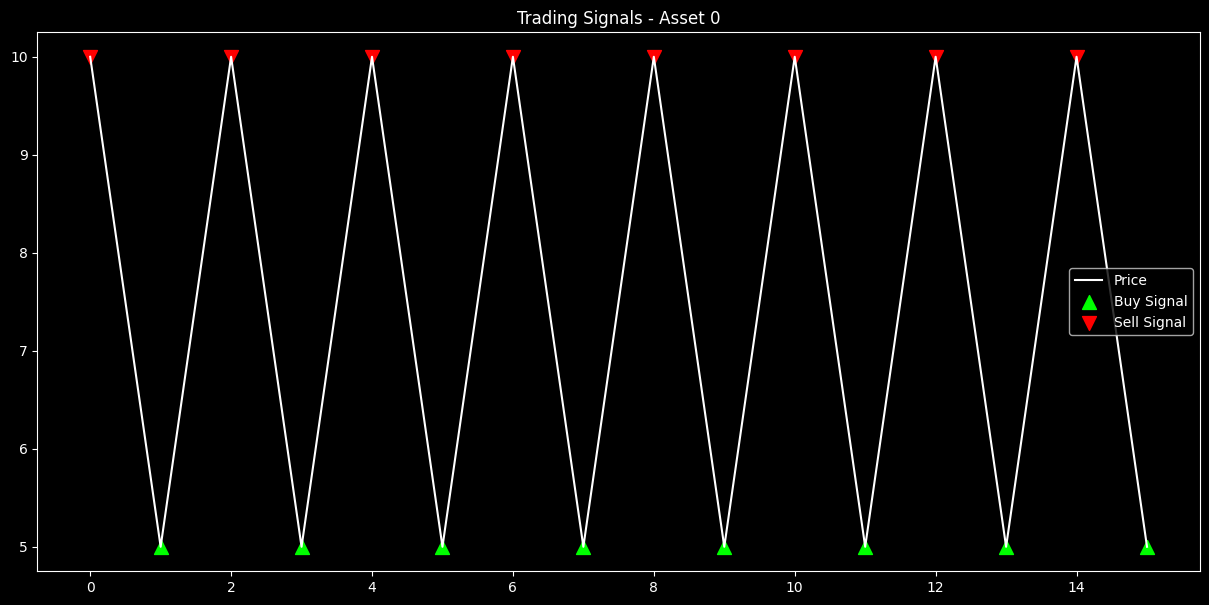

In [105]:
# --- Evaluation ---
policy.eval()
focus_steps = steps
initial_eval_states = torch.zeros((1, n_assets, 3)).to(device)
initial_eval_states[:, :, 0] = 100
eval_indices = torch.zeros(1, dtype=torch.long).to(device)
initial_eval_inputs = build_inputs(initial_eval_states, test_features[eval_indices], test_prices[eval_indices])

eval_context = {
    "prices": test_prices,
    "n_assets": n_assets,
    "flexibility": flexibility,
    "indices": eval_indices,
    "features": test_features,
    "beta": beta,
    "sleep_deficit": torch.ones(1, device=device),
    "gamma_penalty": gamma_penalty,
    "samples": 1
}

with torch.no_grad():
    states_eval, _, actions_eval, _, _ = run_policy(
        1,
        focus_steps,
        eval_context,
        helpers_modifier,
        initial_eval_states,
        initial_eval_inputs,
        policy,
        torch_transition,
        torch_reward
    )

value_curve = states_eval[0, 0, :, 1, 0].unsqueeze(-1)
actions_sequence = actions_eval[0, 0]

plot_trade_actions(test_prices[:focus_steps], actions_sequence, 0, flexibility)

The final visualization confirms that the agent reached the expected results. The model effectively buys at the price floor and sells at the ceiling. This behavior shows that the GRPO algorithm successfully converged to the most efficient trading strategy for this specific environment.